In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns


In [13]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [14]:
df.shape

(918, 12)

In [15]:
df.info()
df.describe()
df['HeartDisease'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,count
HeartDisease,
1,508
0,410


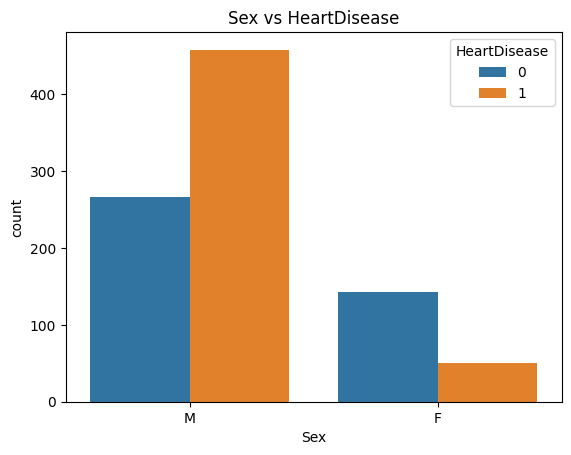

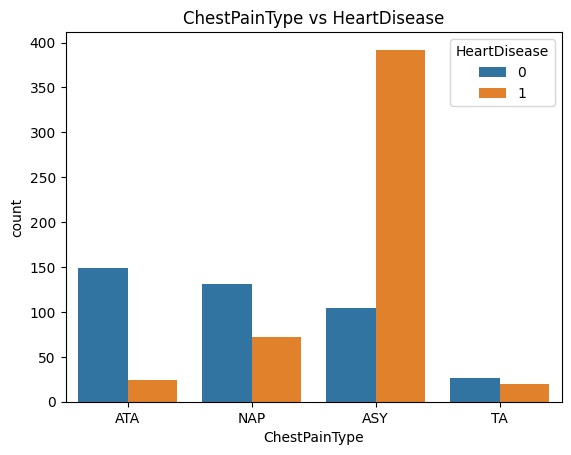

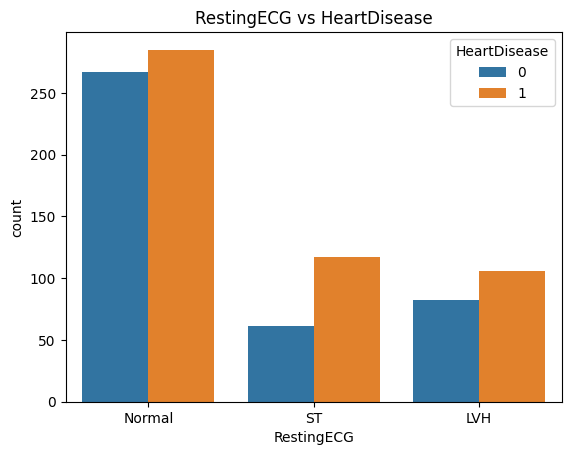

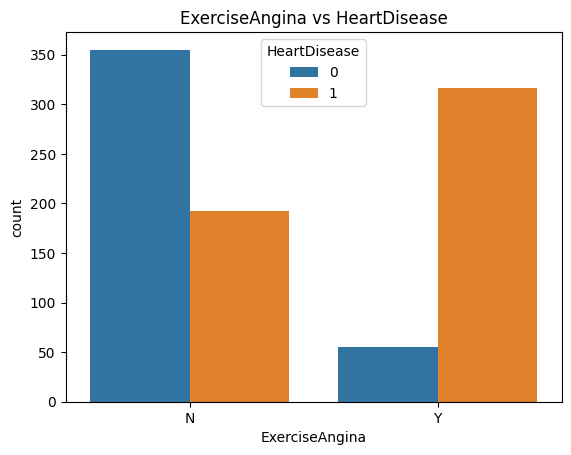

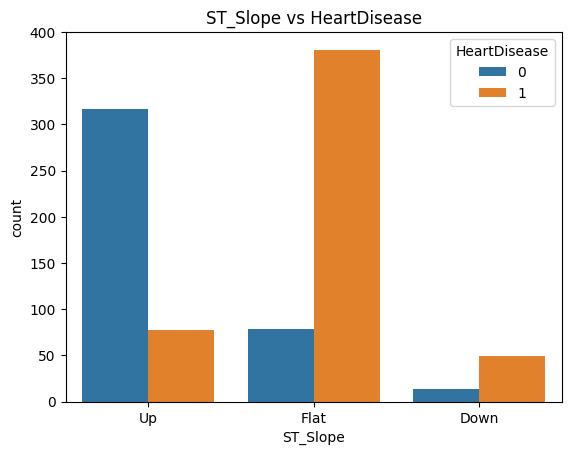

In [16]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cat_cols:
    sns.countplot(data=df, x=col, hue='HeartDisease')
    plt.title(f'{col} vs HeartDisease')
    plt.show()

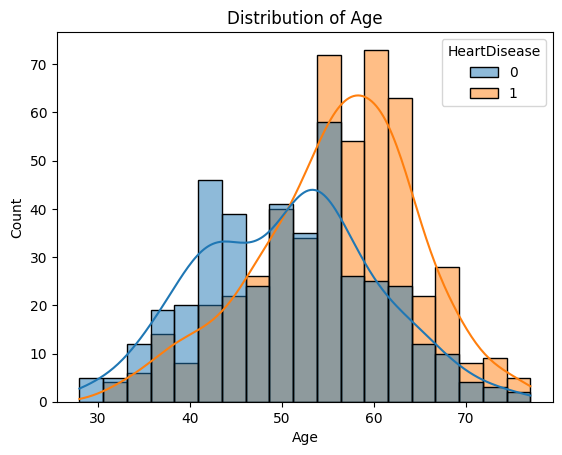

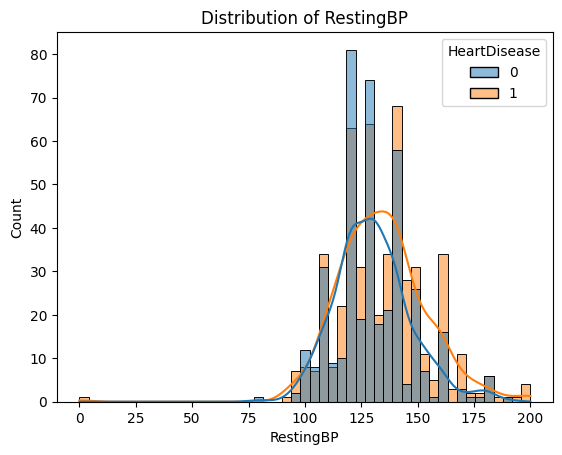

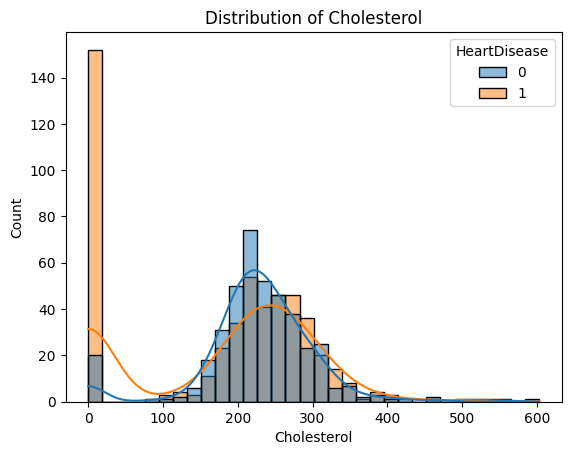

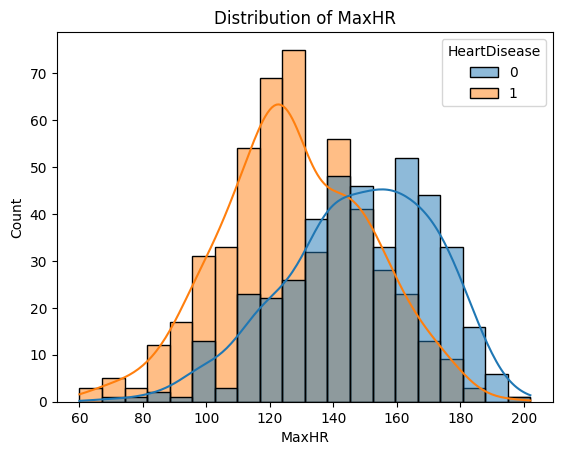

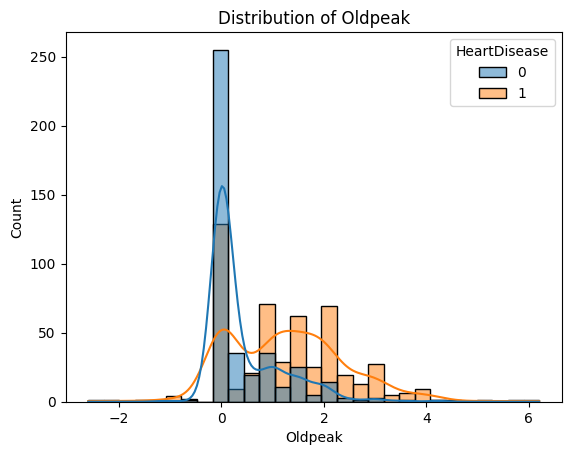

In [17]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in num_cols:
    sns.histplot(data=df, x=col, hue='HeartDisease', kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

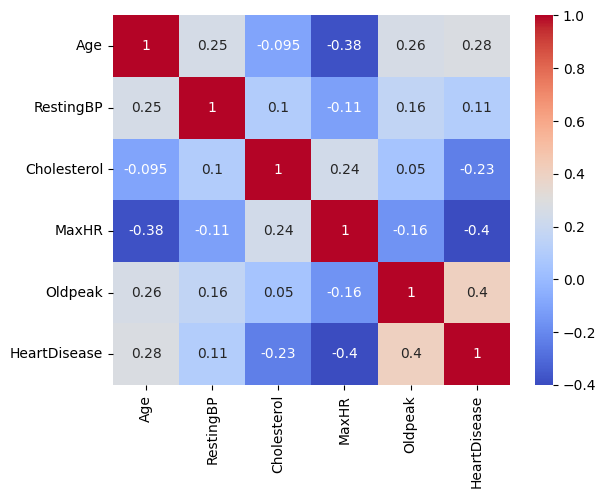

In [18]:
sns.heatmap(df[num_cols + ['HeartDisease']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [19]:
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

# Cholesterol: ~172 bad rows — replace 0 with group-wise median
for target in [0, 1]:
    median_chol = df[(df['HeartDisease'] == target) & (df['Cholesterol'] > 0)]['Cholesterol'].median()
    mask = (df['HeartDisease'] == target) & (df['Cholesterol'] == 0)
    df.loc[mask, 'Cholesterol'] = median_chol

/tmp/ipykernel_8916/2570840614.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '231.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'Cholesterol'] = median_chol


In [20]:
print(df[['RestingBP', 'Cholesterol']].describe())

        RestingBP  Cholesterol
count  918.000000   918.000000
mean   132.538126   244.575163
std     17.990127    53.356165
min     80.000000    85.000000
25%    120.000000   214.000000
50%    130.000000   246.000000
75%    140.000000   267.000000
max    200.000000   603.000000


In [21]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [22]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)                      # train
    y_pred = model.predict(X_test)                   # class predictions
    y_proba = model.predict_proba(X_test)[:, 1]      # probability of disease

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

In [27]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0        Random Forest  0.891304   0.894231  0.911765  0.902913  0.939264
1                  SVM  0.864130   0.873786  0.882353  0.878049  0.938666
2              XGBoost  0.875000   0.891089  0.882353  0.886700  0.936514
3  Logistic Regression  0.891304   0.894231  0.911765  0.902913  0.934959


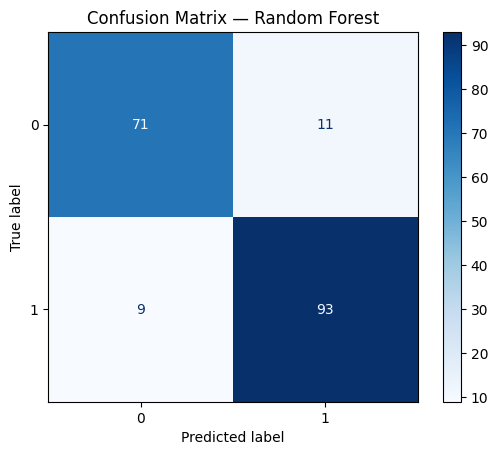

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = models['Random Forest']
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()

In [29]:
import joblib
joblib.dump(best_model, 'heart_disease_model.pkl')

['heart_disease_model.pkl']